# Chapter 12: Gas Processing and Conditioning

This notebook demonstrates gas processing concepts using NeqSim:
- Water content of natural gas at various conditions
- Joule-Thomson (JT) cooling for dew point control
- Turbo-expander process temperature profiles
- Dew point control: C3+ content vs processing temperature

Gas conditioning removes water and heavy hydrocarbons to meet pipeline and sales gas specifications.

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch11_gas_processing_figures.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# NeqSim class imports
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Heater = jneqsim.process.equipment.heatexchanger.Heater
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Compressor = jneqsim.process.equipment.compressor.Compressor
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


## Figure 1: Water Content of Natural Gas vs Temperature

Water content in natural gas is critical for hydrate and corrosion management.
We use CPA EOS to model water partitioning between gas and aqueous phases.

ch11_gas_processing_figures.ipynb:cell4:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


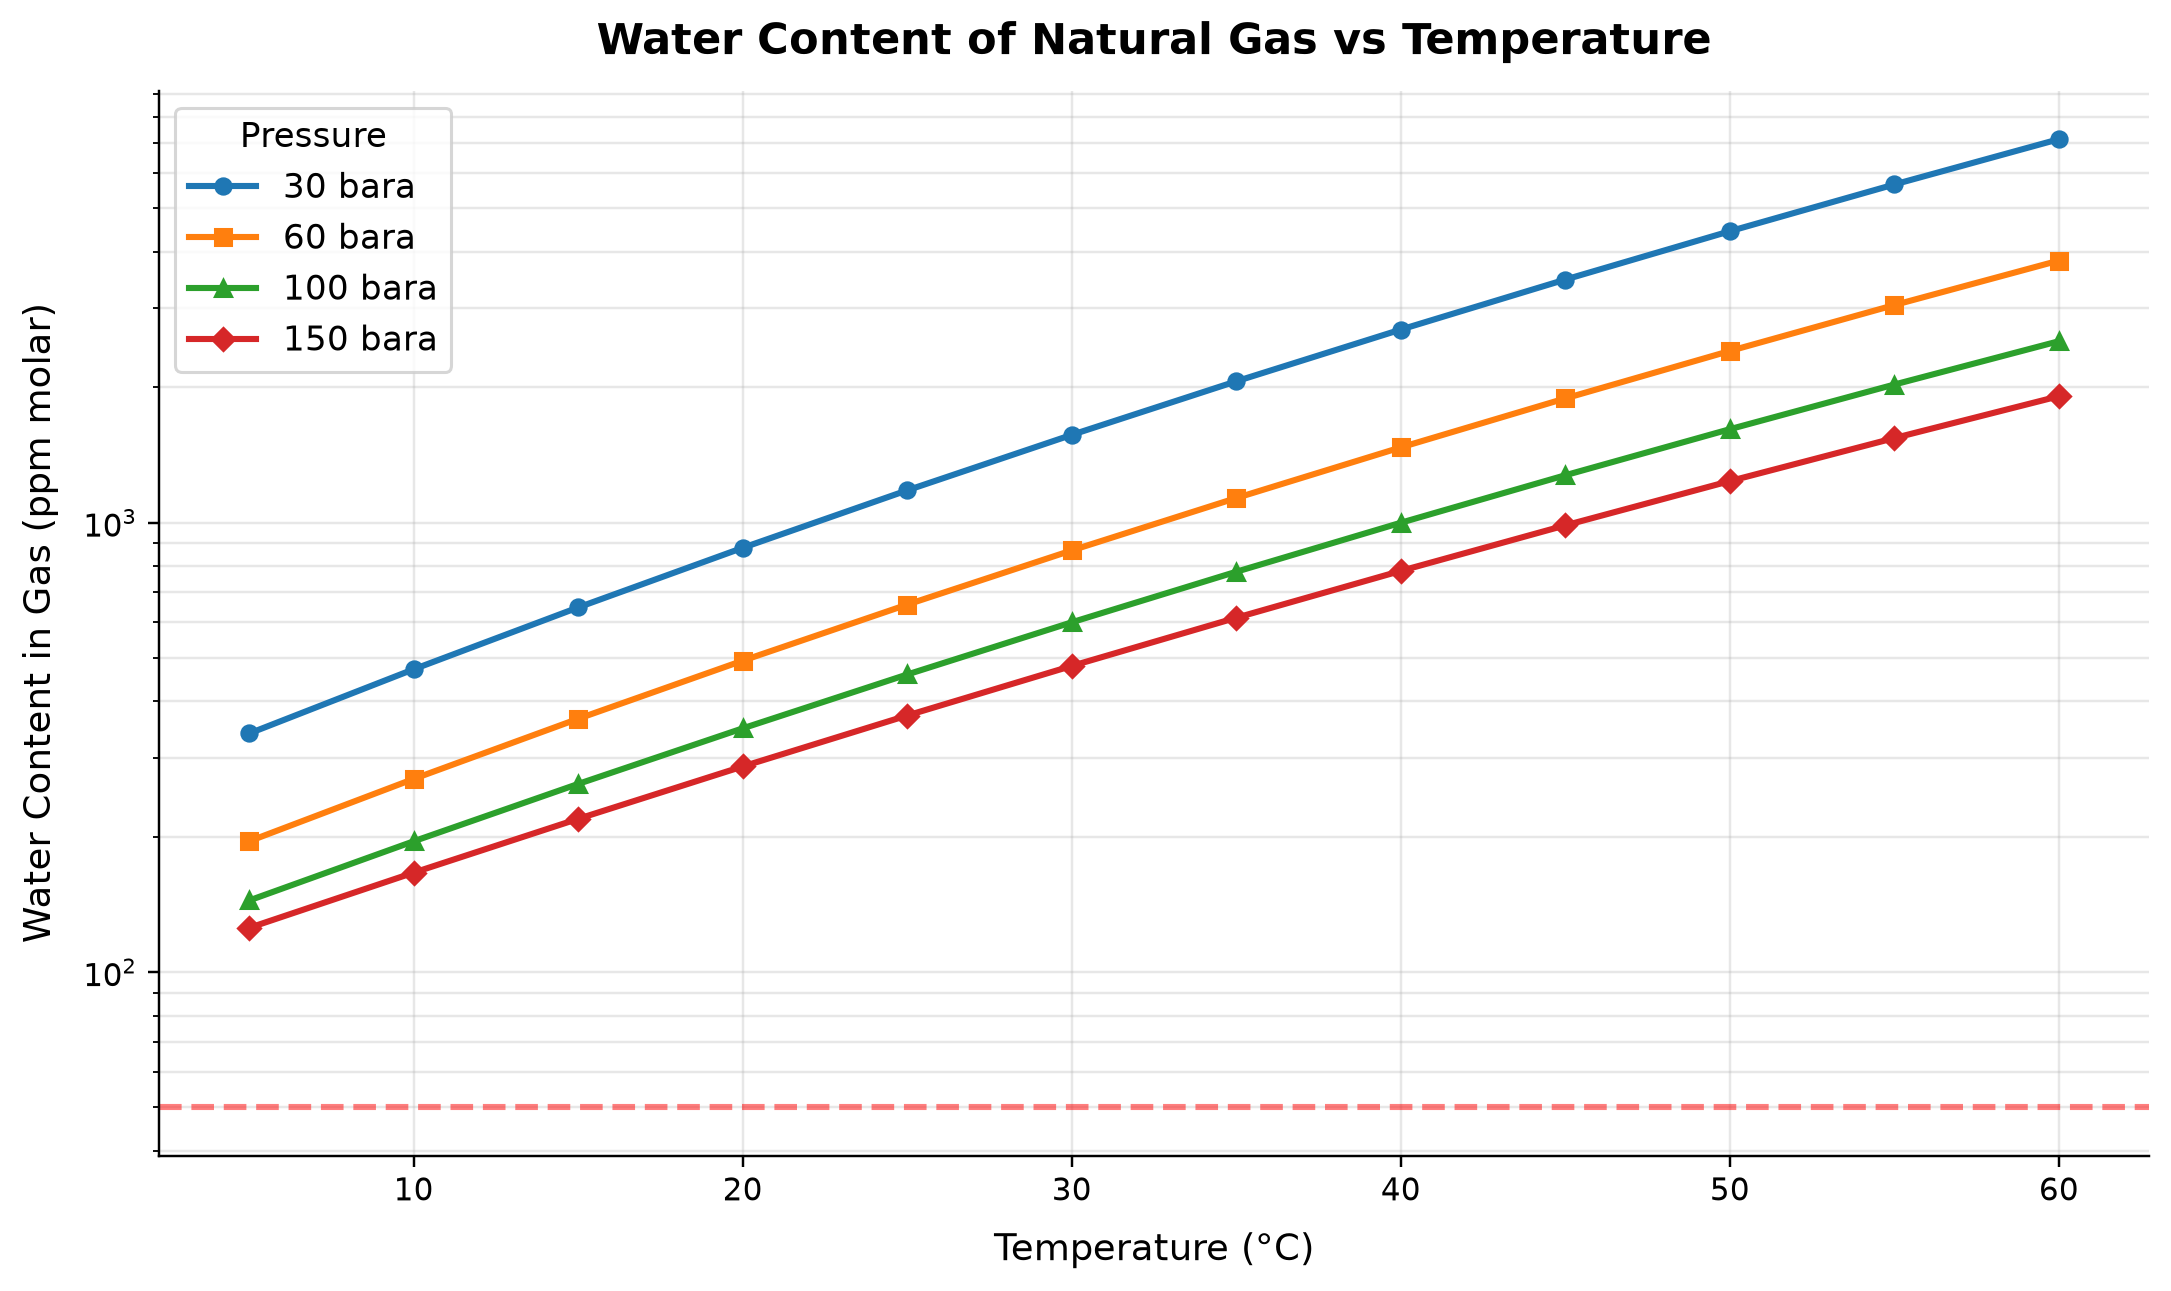

In [3]:
temperatures_C = np.arange(5, 65, 5)
pressures_test = [30.0, 60.0, 100.0, 150.0]
water_content_results = {}

for p in pressures_test:
    water_ppm_list = []
    for t in temperatures_C:
        fluid = SystemSrkCPAstatoil(273.15 + float(t), float(p))
        fluid.addComponent("methane", 0.90)
        fluid.addComponent("ethane", 0.05)
        fluid.addComponent("propane", 0.03)
        fluid.addComponent("n-butane", 0.01)
        fluid.addComponent("water", 0.01)
        fluid.setMixingRule(10)  # CPA mixing rule
        fluid.setMultiPhaseCheck(True)

        ops = ThermodynamicOperations(fluid)
        ops.TPflash()
        fluid.initProperties()
        assert _physics.state(fluid, 'calculation_cell_4:fluid', candidate=False)

        # Get water mole fraction in gas phase
        if fluid.hasPhaseType("gas"):
            gas_phase = fluid.getPhase("gas")
            y_water = float(gas_phase.getComponent("water").getx()) * 1e6  # ppm molar
            water_ppm_list.append(y_water)
        else:
            water_ppm_list.append(float('nan'))

    water_content_results[p] = water_ppm_list

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
markers = ['o', 's', '^', 'D']

for i, p in enumerate(pressures_test):
    ax.semilogy(temperatures_C, water_content_results[p],
                color=colors[i], marker=markers[i], linewidth=2, markersize=5,
                label=f'{p:.0f} bara')

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Water Content in Gas (ppm molar)', fontsize=12)
ax.set_title('Water Content of Natural Gas vs Temperature', fontsize=14)
ax.legend(title='Pressure', fontsize=11, title_fontsize=11)
ax.grid(True, alpha=0.3, which='both')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Typical pipeline spec')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig11_1_water_content.png', dpi=220, bbox_inches='tight')
plt.show()


**Executed-figure discussion.** 30 bara: water content in gas spans 339.5–7131 ppm molar across the plotted cases. 60 bara: water content in gas spans 195.5–3829 ppm molar across the plotted cases.

Warmer gas in equilibrium with liquid water can carry more water vapor, with pressure and gas composition affecting saturation. Cooling upstream of a dehydration unit may remove bulk water but does not establish the low water content required for export. Specify both saturation state and water-content units, and use a separate dehydration calculation and dew-point check for the treated gas.


**Discussion:** Water content in gas increases exponentially with temperature and decreases with pressure. At typical pipeline operating conditions (30-60 bara, 20-40 °C), the water content may exceed pipeline specifications, requiring dehydration (typically TEG absorption). The CPA EOS provides accurate water-hydrocarbon equilibrium predictions.

## Figure 2: JT Cooling — Outlet Temperature vs Inlet Pressure

A Joule-Thomson valve achieves cooling by isenthalpic expansion. We model the JT valve
at different inlet pressures expanding to a common outlet pressure.

Temperature drop range: 5.0 to 45.2 °C


ch11_gas_processing_figures.ipynb:cell7:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


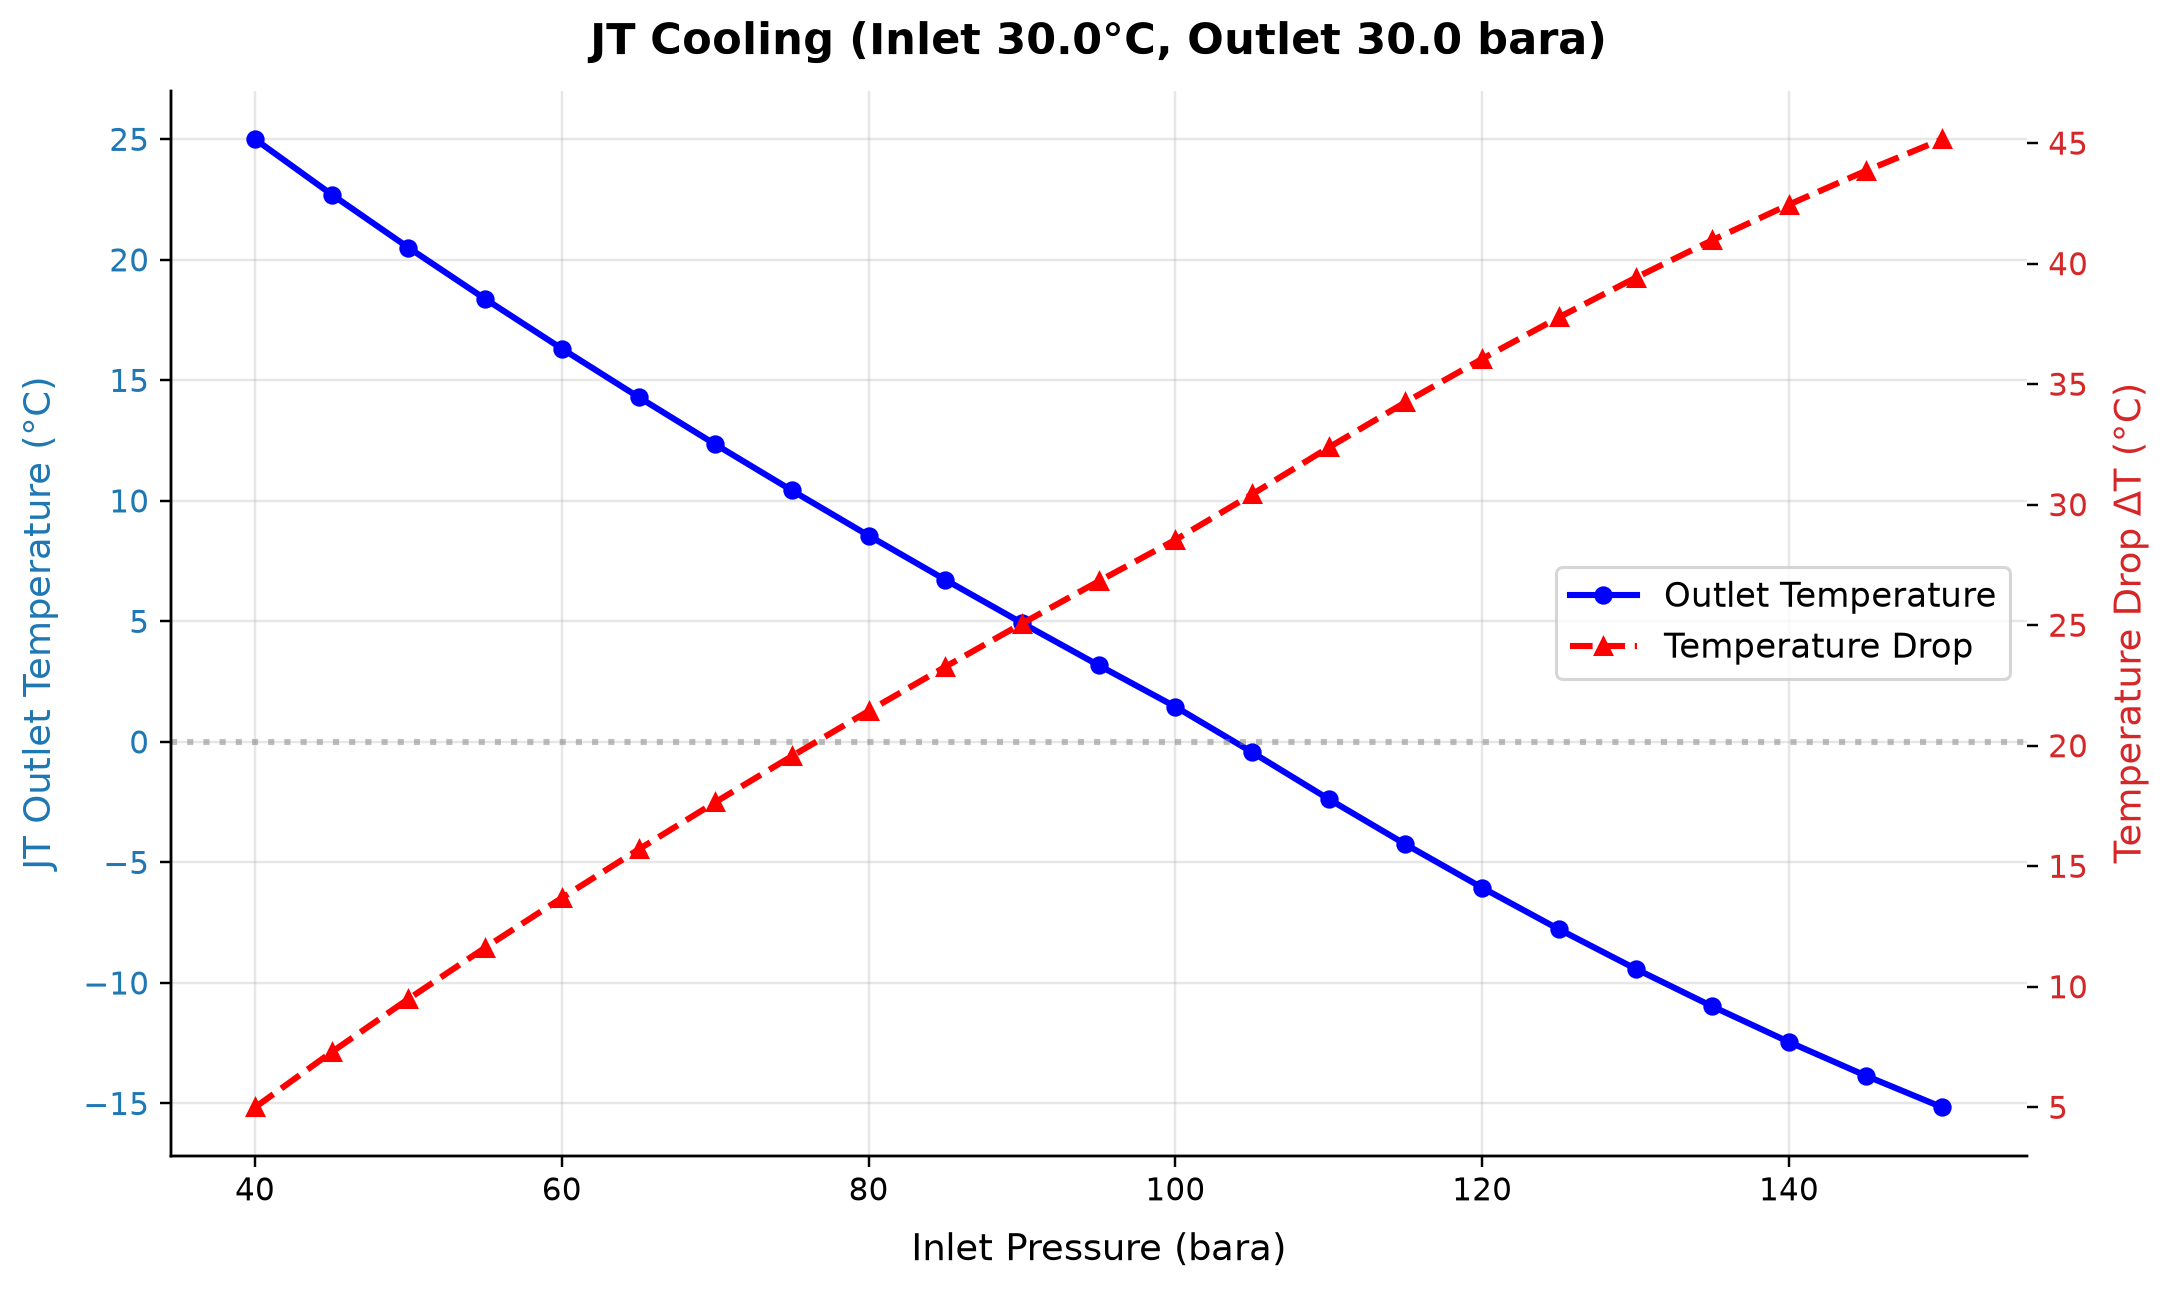

In [4]:
inlet_pressures = np.arange(40, 155, 5)
outlet_pressure = 30.0
inlet_temp_C = 30.0
jt_outlet_temps = []
delta_T_list = []

for p_in in inlet_pressures:
    if float(p_in) <= outlet_pressure:
        jt_outlet_temps.append(float('nan'))
        delta_T_list.append(float('nan'))
        continue

    fluid = SystemSrkEos(273.15 + inlet_temp_C, float(p_in))
    fluid.addComponent("methane", 0.85)
    fluid.addComponent("ethane", 0.07)
    fluid.addComponent("propane", 0.04)
    fluid.addComponent("n-butane", 0.02)
    fluid.addComponent("n-pentane", 0.01)
    fluid.addComponent("n-hexane", 0.01)
    fluid.setMixingRule("classic")

    feed = Stream("feed", fluid)
    feed.setFlowRate(100000.0, "kg/hr")
    feed.run()
    assert _physics.run(feed, 'calculation_cell_7:feed', candidate=False)

    valve = ThrottlingValve("JT valve", feed.getOutletStream())
    valve.setOutletPressure(outlet_pressure)
    valve.run()
    assert _physics.run(valve, 'calculation_cell_7:valve', candidate=False)

    t_out_C = float(valve.getOutletStream().getTemperature("C"))
    jt_outlet_temps.append(t_out_C)
    delta_T_list.append(inlet_temp_C - t_out_C)

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:blue'
valid_idx = [i for i, v in enumerate(jt_outlet_temps) if not np.isnan(v)]
valid_p = [inlet_pressures[i] for i in valid_idx]
valid_t = [jt_outlet_temps[i] for i in valid_idx]
valid_dt = [delta_T_list[i] for i in valid_idx]

ax1.plot(valid_p, valid_t, 'b-o', linewidth=2, markersize=5, label='Outlet Temperature')
ax1.set_xlabel('Inlet Pressure (bara)', fontsize=12)
ax1.set_ylabel('JT Outlet Temperature (°C)', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(valid_p, valid_dt, 'r--^', linewidth=2, markersize=5, label='Temperature Drop')
ax2.set_ylabel('Temperature Drop ΔT (°C)', fontsize=12, color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_title(f'JT Cooling (Inlet {inlet_temp_C}°C, Outlet {outlet_pressure} bara)', fontsize=14)
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig11_2_jt_cooling.png', dpi=220, bbox_inches='tight')
plt.show()
print(f"Temperature drop range: {min(valid_dt):.1f} to {max(valid_dt):.1f} °C")


**Executed-figure discussion.** Outlet Temperature: jt outlet temperature spans -15.16–25 °C across the plotted cases. Temperature Drop: temperature drop δt spans 4.995–45.16 °C across the plotted cases.

Adiabatic throttling conserves enthalpy while pressure reduction changes temperature and potentially condenses liquids. Cooling duty and liquid recovery vary with the full inlet state, so a single constant Joule–Thomson coefficient cannot represent every pressure ratio. Run a PH flash for each letdown case and verify cold-separator load, hydrate margin and the need for gas recompression.


**Discussion:** The JT effect produces larger temperature drops at higher pressure ratios. For natural gas, the JT coefficient is typically 3-5 °C/MPa. Higher inlet pressures yield colder outlet temperatures, enabling deeper NGL recovery and hydrocarbon dew point control without mechanical refrigeration.

## Figure 3: Turbo-Expander Process — Temperature Profile

A turbo-expander achieves deeper cooling than a JT valve by extracting work.
We model: Feed → Compressor → Aftercooler → Expander, showing the temperature at each point.

Equipment Temperature Pressure
Feed                          30.0 °C      70.0 bara
Pre-cooler Outlet             20.0 °C      70.0 bara
Booster Outlet                44.3 °C     100.0 bara
Aftercooler Outlet            30.0 °C     100.0 bara
Expander Outlet              -23.1 °C      30.0 bara


ch11_gas_processing_figures.ipynb:cell10:95: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


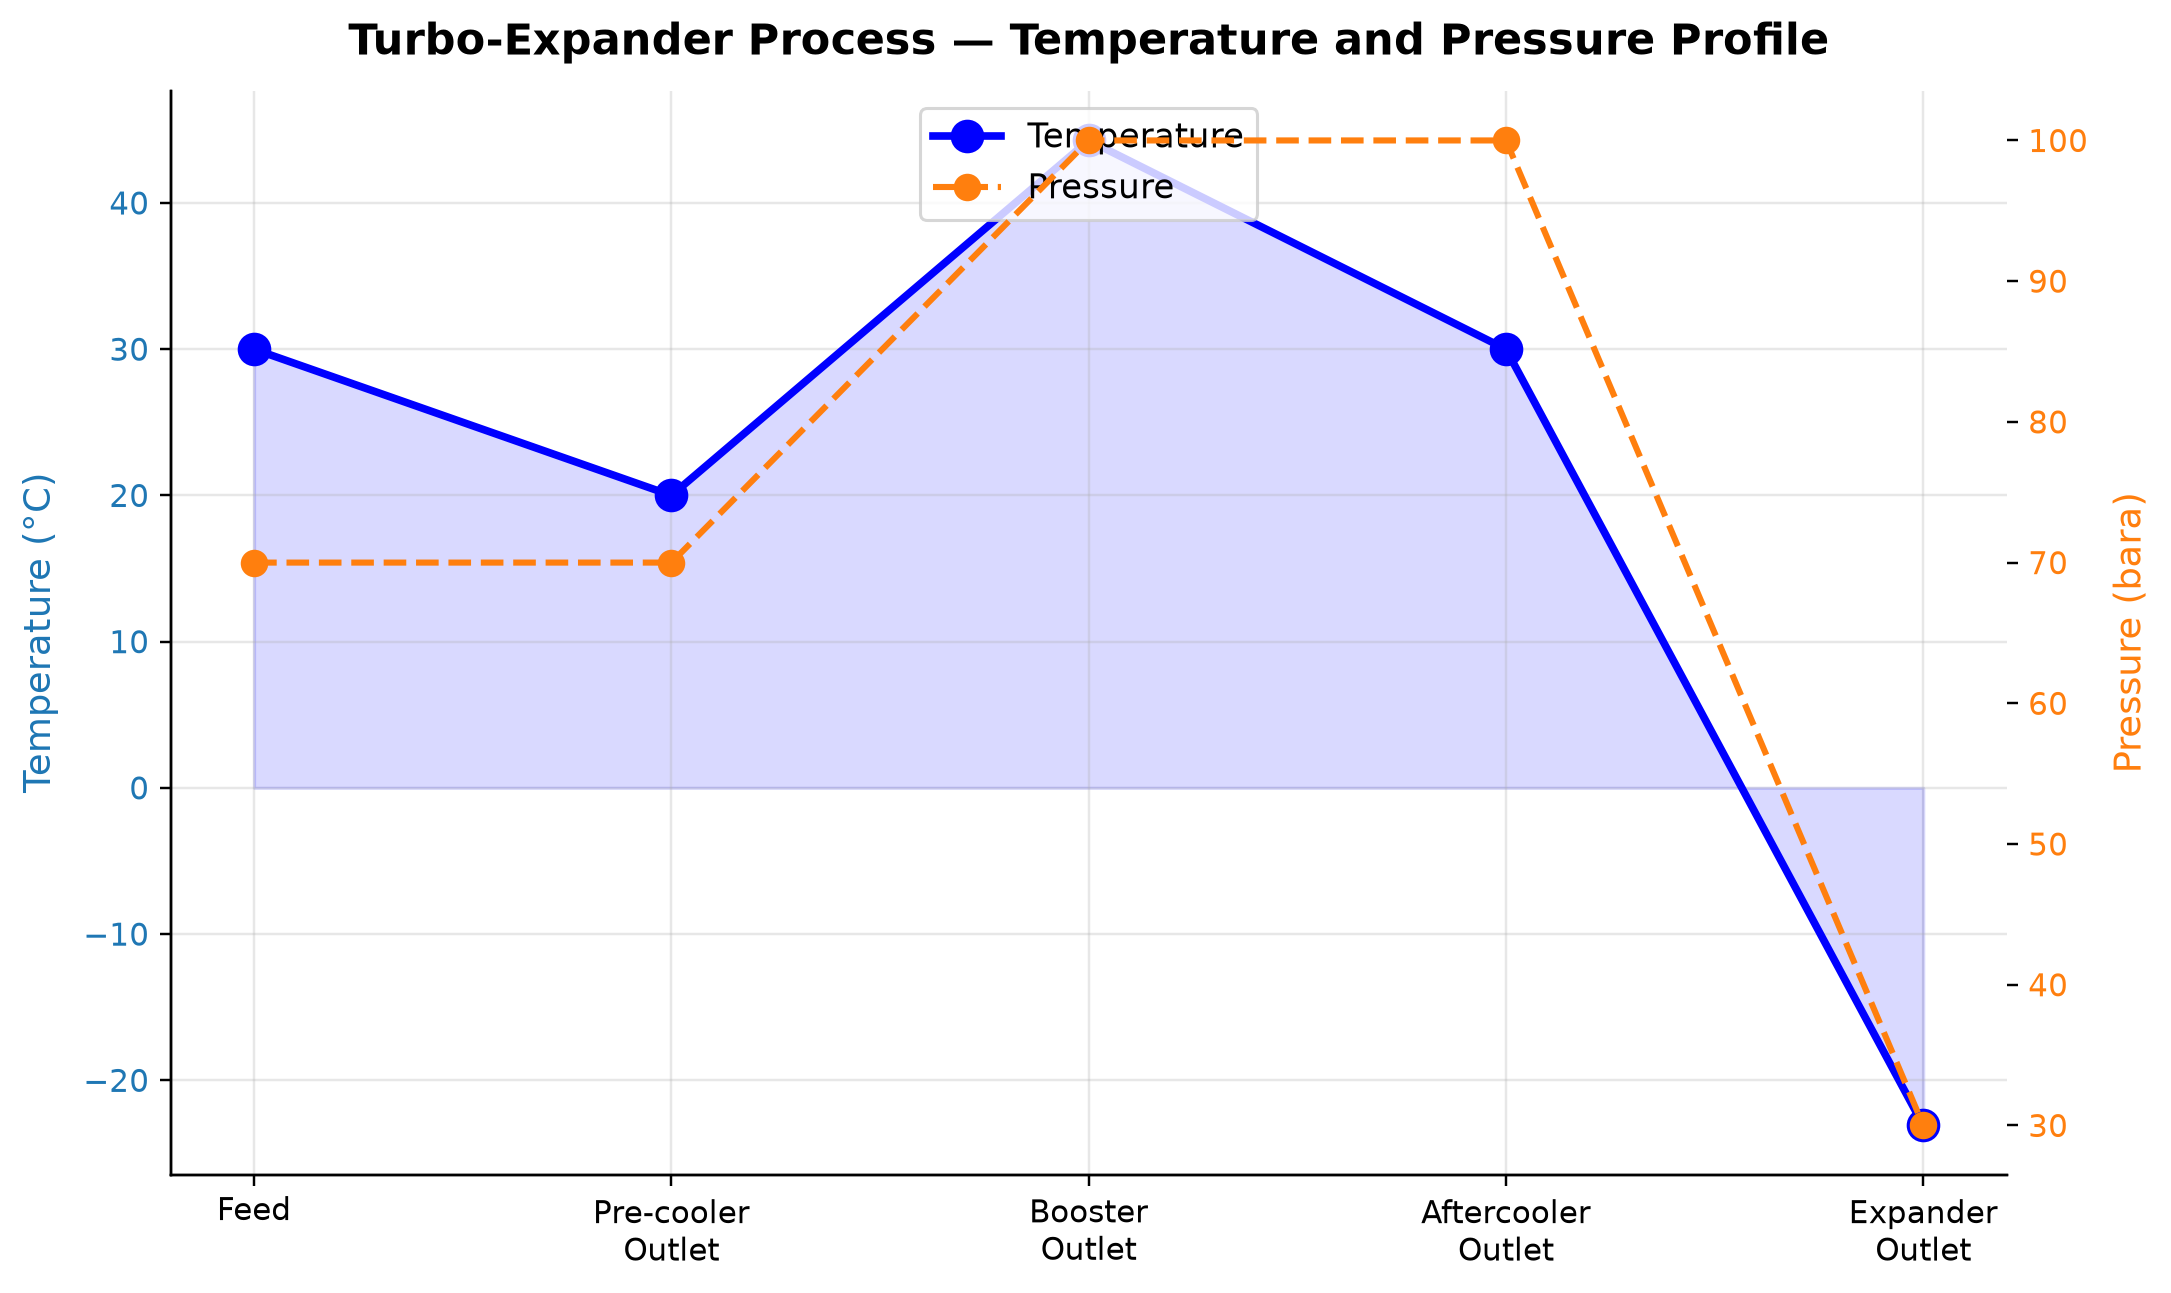

In [5]:
Expander = jneqsim.process.equipment.expander.Expander

# Create rich gas feed
gas_fluid = SystemSrkEos(273.15 + 30.0, 70.0)
gas_fluid.addComponent("methane", 0.82)
gas_fluid.addComponent("ethane", 0.08)
gas_fluid.addComponent("propane", 0.05)
gas_fluid.addComponent("n-butane", 0.02)
gas_fluid.addComponent("n-pentane", 0.01)
gas_fluid.addComponent("n-hexane", 0.01)
gas_fluid.addComponent("nitrogen", 0.01)
gas_fluid.setMixingRule("classic")

# Build process: Feed → Inlet Cooler → Compressor → Aftercooler → Expander
feed = Stream("Feed Gas", gas_fluid)
feed.setFlowRate(50000.0, "kg/hr")
feed.run()
assert _physics.run(feed, 'calculation_cell_10:feed', candidate=False)

# Pre-cool the gas
precooler = Cooler("Pre-cooler", feed.getOutletStream())
precooler.setOutTemperature(273.15 + 20.0)
precooler.run()
assert _physics.run(precooler, 'calculation_cell_10:precooler', candidate=False)

# Boost pressure
booster = Compressor("Booster Compressor", precooler.getOutletStream())
booster.setOutletPressure(100.0)
booster.setUsePolytropicCalc(True)
booster.setPolytropicEfficiency(0.75)
booster.run()
assert _physics.run(booster, 'calculation_cell_10:booster', candidate=False)

# Aftercooler
aftercooler = Cooler("Aftercooler", booster.getOutletStream())
aftercooler.setOutTemperature(273.15 + 30.0)
aftercooler.run()
assert _physics.run(aftercooler, 'calculation_cell_10:aftercooler', candidate=False)

# Turbo-expander
expander = Expander("Turbo-Expander", aftercooler.getOutletStream())
expander.setOutletPressure(30.0)
expander.setUsePolytropicCalc(True)
expander.setPolytropicEfficiency(0.80)
expander.run()
assert _physics.run(expander, 'calculation_cell_10:expander', candidate=False)

# Collect results
equipment_names = ['Feed', 'Pre-cooler\nOutlet', 'Booster\nOutlet', 'Aftercooler\nOutlet', 'Expander\nOutlet']
temperatures = [
    float(feed.getOutletStream().getTemperature("C")),
    float(precooler.getOutletStream().getTemperature("C")),
    float(booster.getOutletStream().getTemperature("C")),
    float(aftercooler.getOutletStream().getTemperature("C")),
    float(expander.getOutletStream().getTemperature("C")),
]
pressures_profile = [
    float(feed.getOutletStream().getPressure("bara")),
    float(precooler.getOutletStream().getPressure("bara")),
    float(booster.getOutletStream().getPressure("bara")),
    float(aftercooler.getOutletStream().getPressure("bara")),
    float(expander.getOutletStream().getPressure("bara")),
]

print("Equipment Temperature Pressure")
for name, t, p in zip(equipment_names, temperatures, pressures_profile):
    print(f"{name.replace(chr(10),' '):25s} {t:8.1f} °C  {p:8.1f} bara")

fig, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(equipment_names))

color1 = 'tab:blue'
ax1.plot(x, temperatures, 'b-o', linewidth=2.5, markersize=10, label='Temperature', zorder=5)
ax1.fill_between(x, temperatures, alpha=0.15, color='blue')
ax1.set_ylabel('Temperature (°C)', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.plot(x, pressures_profile, 'o--', color=color2, linewidth=2, markersize=8, label='Pressure')
ax2.set_ylabel('Pressure (bara)', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_xticks(x)
ax1.set_xticklabels(equipment_names, fontsize=10)
ax1.set_title('Turbo-Expander Process — Temperature and Pressure Profile', fontsize=14)
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig11_3_turbo_expander_profile.png', dpi=220, bbox_inches='tight')
plt.show()


**Executed-figure discussion.** Temperature spans -23.09–44.27 °C across the plotted cases. Pressure spans 30–100 bara across the plotted cases.

The expander removes shaft work from the gas, lowering its enthalpy; subsequent separation redistributes the condensed liquids. The temperature profile depends on expansion efficiency and stage boundary conditions, not only on the overall pressure drop. Close the process energy balance and check expander liquid tolerance, minimum temperature and recovered-power use.


**Discussion:** The turbo-expander achieves significantly colder outlet temperatures than a JT valve at the same pressure ratio because it extracts work from the gas. The compressor outlet shows a temperature increase that must be removed by the aftercooler. The very low expander outlet temperature (-40 to -60 °C typical) enables deep NGL recovery, making this the standard process for ethane-plus recovery in gas plants.

## Figure 4: Dew Point Control — C3+ Content vs Processing Temperature

The hydrocarbon dew point specification limits heavy hydrocarbons in sales gas.
We cool the gas to different temperatures, separate liquids, and measure C3+ in the gas.

C3+ at -30°C: 2.81 mol%
C3+ at +20°C: 7.18 mol%


ch11_gas_processing_figures.ipynb:cell13:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


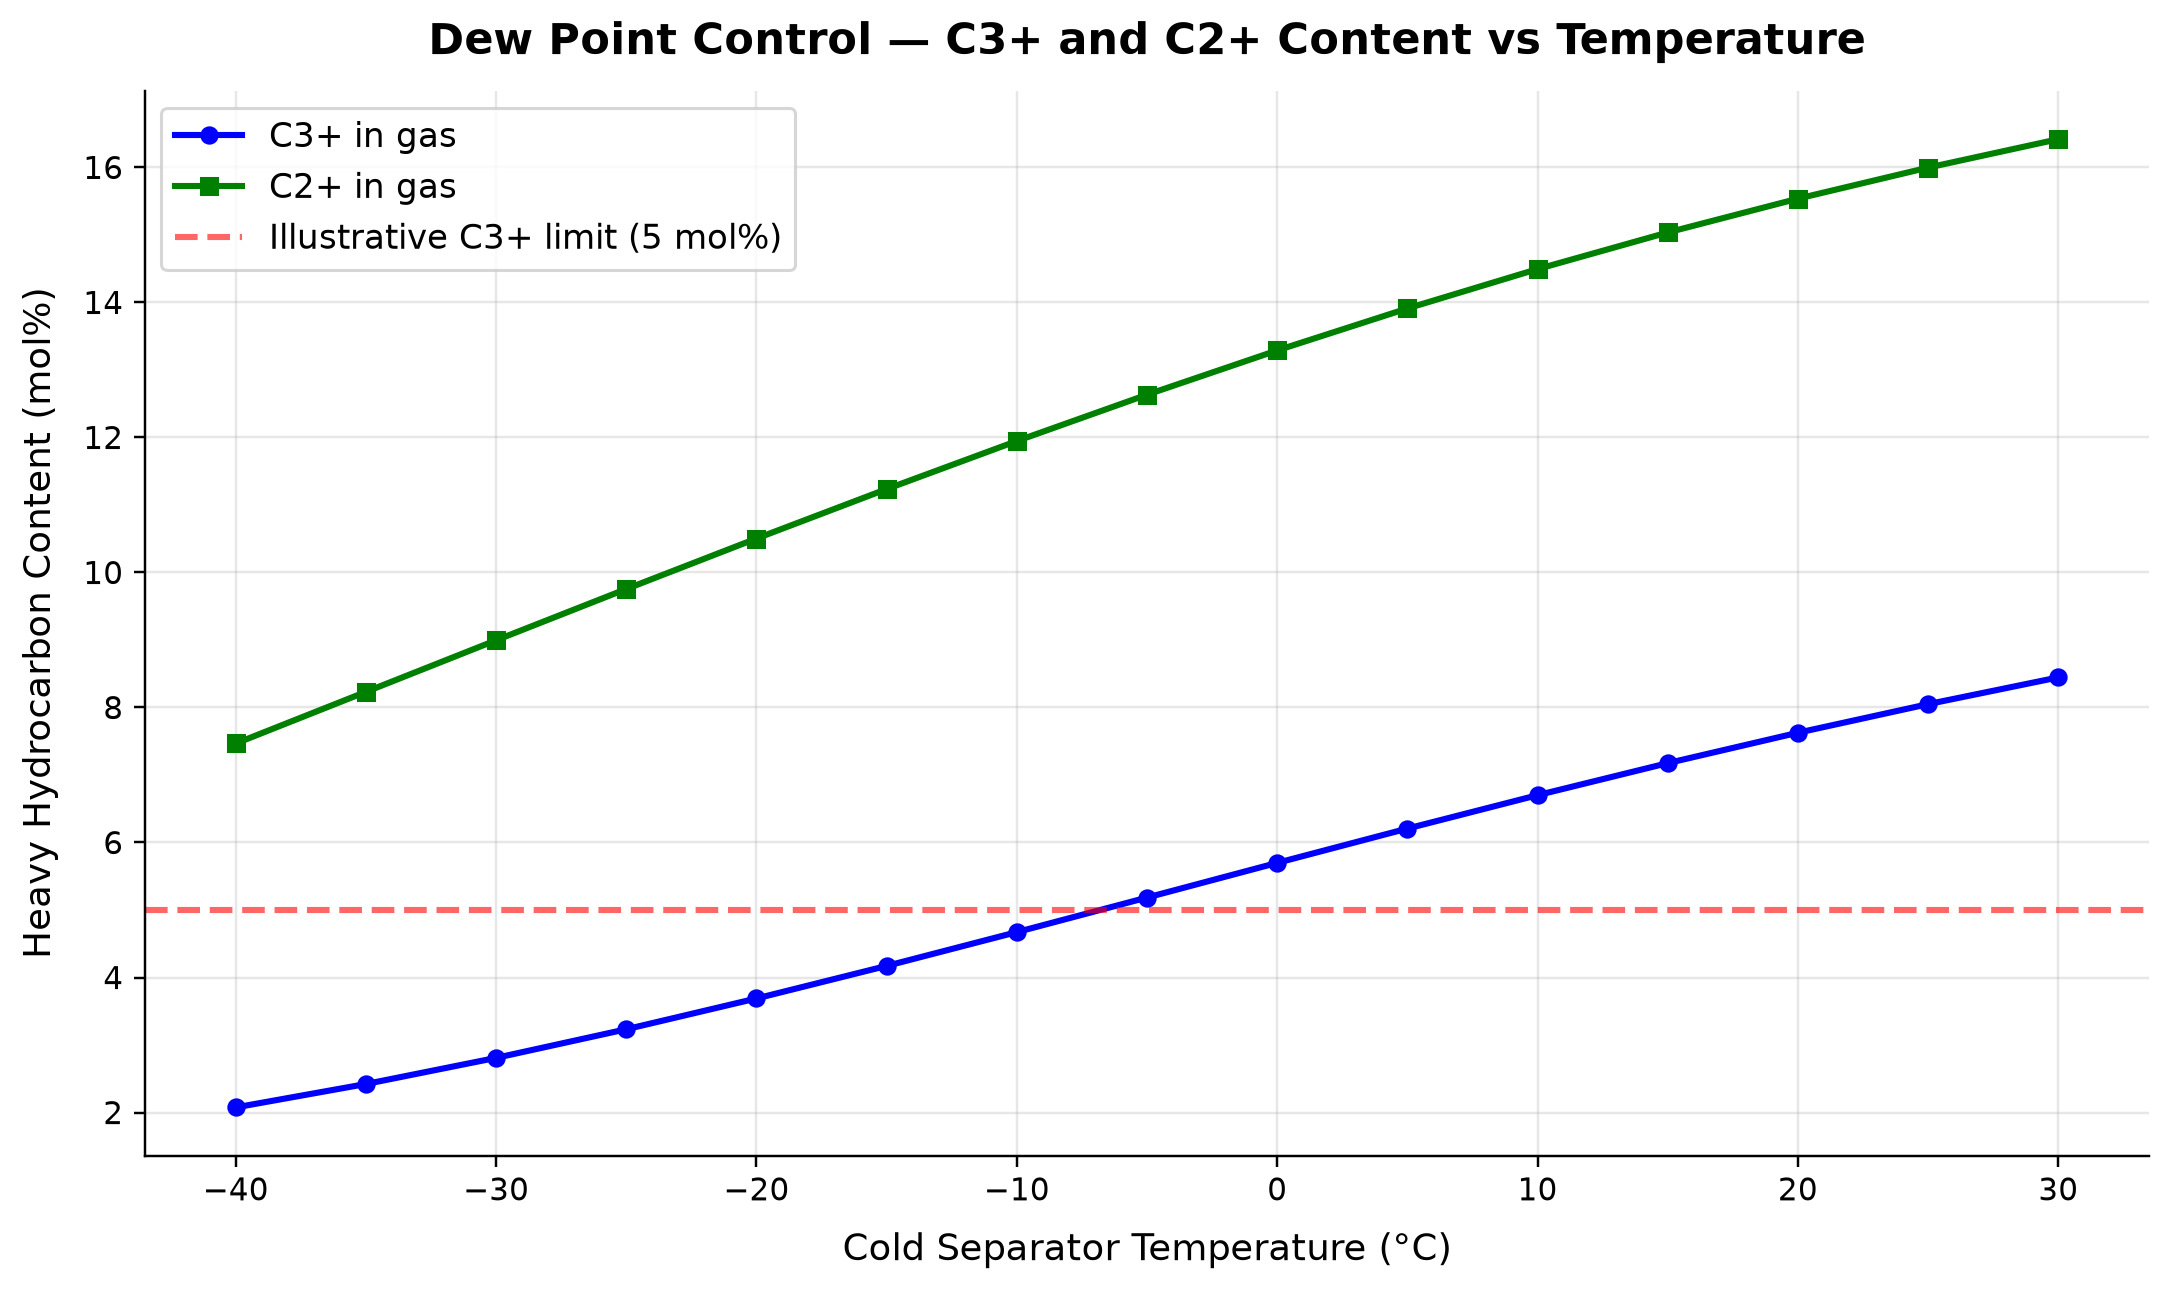

In [6]:
cold_sep_temps_C = np.arange(-40, 35, 5)
c3plus_in_gas = []
c2plus_in_gas = []

for t_cold in cold_sep_temps_C:
    fluid = SystemSrkEos(273.15 + float(t_cold), 60.0)
    fluid.addComponent("methane", 0.82)
    fluid.addComponent("ethane", 0.08)
    fluid.addComponent("propane", 0.05)
    fluid.addComponent("n-butane", 0.02)
    fluid.addComponent("i-butane", 0.01)
    fluid.addComponent("n-pentane", 0.01)
    fluid.addComponent("n-hexane", 0.005)
    fluid.addComponent("n-heptane", 0.005)
    fluid.setMixingRule("classic")

    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()
    assert _physics.state(fluid, 'calculation_cell_13:fluid', candidate=False)

    if fluid.hasPhaseType("gas"):
        gas = fluid.getPhase("gas")
        # Sum C3+ mole fractions
        c3p = 0.0
        c2p = 0.0
        for comp_name in ["propane", "n-butane", "i-butane", "n-pentane", "n-hexane", "n-heptane"]:
            c3p += float(gas.getComponent(comp_name).getx())
        c2p = c3p + float(gas.getComponent("ethane").getx())
        c3plus_in_gas.append(c3p * 100)  # mol%
        c2plus_in_gas.append(c2p * 100)
    else:
        c3plus_in_gas.append(float('nan'))
        c2plus_in_gas.append(float('nan'))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cold_sep_temps_C, c3plus_in_gas, 'b-o', linewidth=2, markersize=5, label='C3+ in gas')
ax.plot(cold_sep_temps_C, c2plus_in_gas, 'g-s', linewidth=2, markersize=5, label='C2+ in gas')

ax.axhline(y=5.0, color='red', linestyle='--', alpha=0.6, label='Illustrative C3+ limit (5 mol%)')
ax.set_xlabel('Cold Separator Temperature (°C)', fontsize=12)
ax.set_ylabel('Heavy Hydrocarbon Content (mol%)', fontsize=12)
ax.set_title('Dew Point Control — C3+ and C2+ Content vs Temperature', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig11_4_dewpoint_control.png', dpi=220, bbox_inches='tight')
plt.show()
print(f"C3+ at -30°C: {c3plus_in_gas[2]:.2f} mol%")
print(f"C3+ at +20°C: {c3plus_in_gas[-4]:.2f} mol%")


**Executed-figure discussion.** C3+ in gas: heavy hydrocarbon content spans 2.076–8.445 mol% across the plotted cases. C2+ in gas: heavy hydrocarbon content spans 7.467–16.42 mol% across the plotted cases.

Lower cold-separator temperature transfers heavier hydrocarbons preferentially to liquid and changes the residual C2+ and C3+ gas fractions. Composition reduction is an indicator of treatment severity, but the actual hydrocarbon dew point must still be calculated at the contract pressure. Choose the least-cost feasible cooling level using both gas quality and recovered-liquid value, including pressure loss and recompression demand.


**Discussion:** Lower cold separator temperatures remove more heavy hydrocarbons from the gas, reducing both C3+ and C2+ content. The exponential decrease shows that moderate cooling (to about -10 to -20 °C with JT) can meet typical pipeline specs, while deeper cooling (below -40 °C with turbo-expander) is needed for ethane recovery. The balance between NGL recovery revenue and processing cost determines the optimal processing temperature.

## Summary

Key takeaways from gas processing and conditioning:

1. **Water content** increases exponentially with temperature; dehydration is needed for most pipeline specifications
2. **JT cooling** provides simple dew point control but limited temperature reduction (~3-5 °C/MPa)
3. **Turbo-expanders** achieve much deeper cooling for NGL recovery by extracting work from the gas
4. **Cold separator temperature** directly controls the amount of heavy hydrocarbons remaining in sales gas

These processes form the core of gas plant operations and offshore gas conditioning systems.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [7]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                            Figure  Panel                          Series                    Output / unit  Minimum  Maximum  Finite points  Missing points
         fig11_1_water_content.png      1                         30 bara Water Content in Gas (ppm molar)  339.515  7130.55             12               0
         fig11_1_water_content.png      1                         60 bara Water Content in Gas (ppm molar)  195.471  3828.55             12               0
         fig11_1_water_content.png      1                        100 bara Water Content in Gas (ppm molar)   144.33  2533.02             12               0
         fig11_1_water_content.png      1                        150 bara Water Content in Gas (ppm molar)  125.427   1910.7             12               0
         fig11_1_water_content.png      1           Typical pipeline spec Water Content in Gas (ppm molar)       50       50              2               0
            fig11_2_jt_cooling.png      1              Outlet Te

## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [8]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 242 distinct checks, 2844 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

Water-content bounds, JT first law and heavy-component nesting. No independent gas-conditioning recovery or dew-point dataset.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
